In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('logs_sistema.csv')

In [10]:
df.head()

,ID_Evento,Timestamp_UTC,Nivel_Log,Servico_Afetado,Codigo_Erro,Tempo_Resposta_MS,Usuario_ID,Memoria_Consumida_MB
0,2001,2024-01-05 10:00:15,INFO,Autenticacao,N/A,120,U001,256
1,2002,2024-01-05 10:01:30,ERROR,Pagamentos,E2001,500,U002,512
2,2003,2024-01-05 10:02:05,WARNING,Estoque,N/A,800,U003,300
3,2004,2024-01-05 10:03:10,INFO,Frontend,N/A,90,U004,200
4,2005,2024-01-05 10:04:45,CRITICAL,Pagamentos,E2002,1200,NaN,700


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID_Evento             50 non-null     int64 
 1   Timestamp_UTC         50 non-null     object
 2   Nivel_Log             50 non-null     object
 3   Servico_Afetado       50 non-null     object
 4   Codigo_Erro           20 non-null     object
 5   Tempo_Resposta_MS     50 non-null     int64 
 6   Usuario_ID            45 non-null     object
 7   Memoria_Consumida_MB  50 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 3.3+ KB


In [14]:
df['Codigo_Erro'] = df['Codigo_Erro'].fillna('N/A')

In [13]:
df['Timestamp_UTC'] = pd.to_datetime(df['Timestamp_UTC'], utc=True)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   ID_Evento             50 non-null     int64              
 1   Timestamp_UTC         50 non-null     datetime64[ns, UTC]
 2   Nivel_Log             50 non-null     object             
 3   Servico_Afetado       50 non-null     object             
 4   Codigo_Erro           50 non-null     object             
 5   Tempo_Resposta_MS     50 non-null     int64              
 6   Usuario_ID            45 non-null     object             
 7   Memoria_Consumida_MB  50 non-null     int64              
dtypes: datetime64[ns, UTC](1), int64(3), object(4)
memory usage: 3.3+ KB


Foi tratado os dados vazios na coluna 'Codigo_Erro' e realizado a conversão da coluna 'Timestamp_UTC' para campos padrão de tempo feito pela biblioteca pandas. Resumindo: tratando os dados para deixar num padrão mais conveniente que facilite a posterior análise de dados sobre o dataset 'logs_sistema.csv'.

In [30]:
dataLogs = df['Nivel_Log'].value_counts()

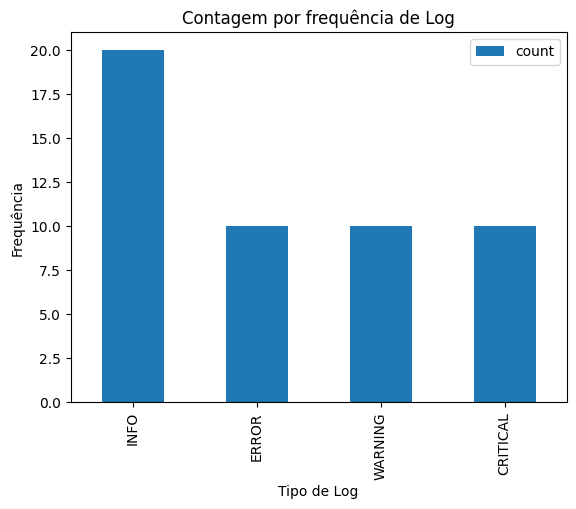

In [41]:
df_plot = pd.DataFrame(dataLogs)
df_plot.plot(kind='bar')

plt.xlabel('Tipo de Log')
plt.ylabel('Frequência')
plt.title('Contagem por frequência de Log')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.show()

In [34]:
dataServicos = df['Servico_Afetado'].value_counts()

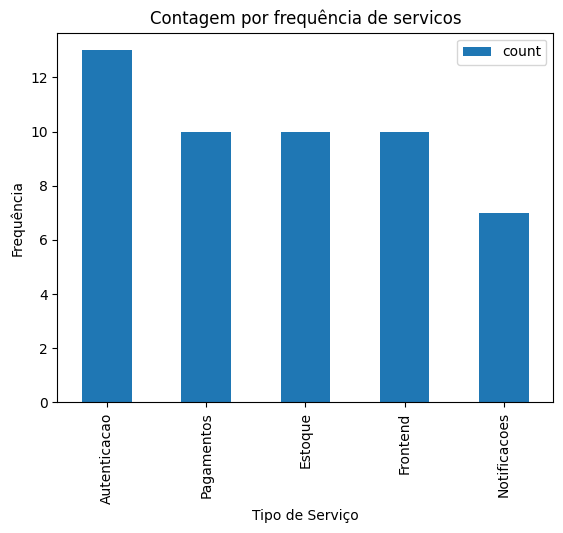

In [40]:
df_plot = pd.DataFrame(dataServicos)
df_plot.plot(kind='bar')

plt.xlabel('Tipo de Serviço')
plt.ylabel('Frequência')
plt.title('Contagem por frequência de servicos')

plt.show()

Análise das frequências de serviços e tipos de logs que ocorreram no sistema através de gráfico de barras.

In [49]:
dfLogsErros = df[df['Nivel_Log'].isin(['ERROR', 'CRITICAL'])]

In [48]:
dfLogsErros.groupby('Servico_Afetado').size().sort_values(ascending=False)


,0
Servico_Afetado,
Autenticacao,8
Pagamentos,8
Estoque,2
Notificacoes,2


Ambos os serviços 'Autenticacao' e 'Pagamentos' são os mais problemáticos comparando aos outros serviços, com os dois apresentando no total 8 erros de logs em cada um.

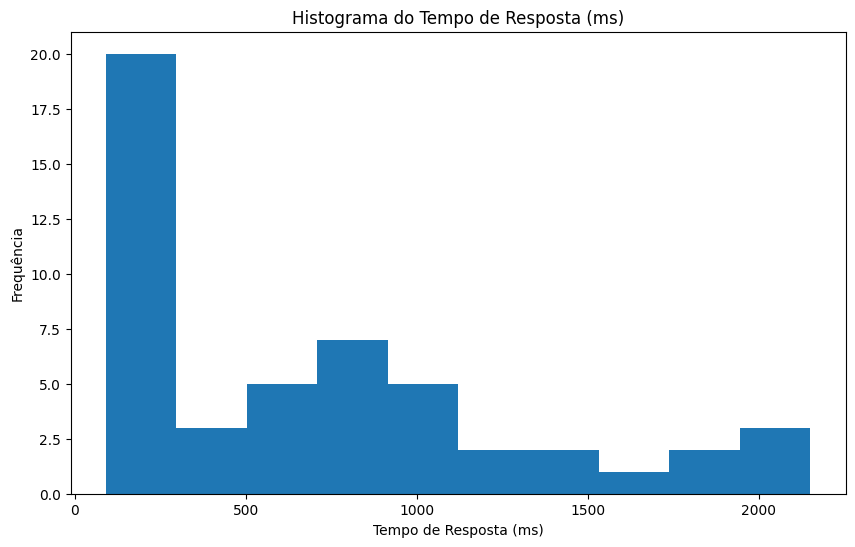

In [53]:
plt.figure(figsize=(10, 6))
plt.hist(df['Tempo_Resposta_MS'])

plt.xlabel('Tempo de Resposta (ms)')
plt.ylabel('Frequência')
plt.title('Histograma do Tempo de Resposta (ms)')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()
plt.show()

In [55]:
idx_max = df['Tempo_Resposta_MS'].idxmax()

evento_mais_lento = df.loc[idx_max, ['ID_Evento', 'Nivel_Log', 'Servico_Afetado', 'Tempo_Resposta_MS']]

print(evento_mais_lento)

ID_Evento                    2050
Nivel_Log                CRITICAL
Servico_Afetado      Autenticacao
Tempo_Resposta_MS            2150
Name: 49, dtype: object


A maioria do tempo de resposta em ms foram rápidas, abaixo dos 500 ms se encontram a maioria delas. O 'ID_Evento' que possui o maior 'Tempo_Resposta_MS' foi o ID 2050, com o nível de log mais crítico do sistema 'CRITICAL' e o serviço afetado 'Autenticacao'.

Principal problema: os serviços 'Autenticacao' e 'Pagamento' com muitos erros de logs e quando há a ocorrência desses erros o desempenho pelo tempo de resposta aumentam consideravelmente, representando boa parte desses tempos de resposta altas na faixa de 500 a 2000 ms comparando no histograma de tempo de resposta (ms).

Outro problema: os erros mais críticos 'CRITICAL' e 'ERROR' possuem um gasto de memória maior comparado aos outros níveis de erro.

Como sugestão: É possível dar uma melhorada no código para os serviços 'Autenticacao' e 'Pagamento' para que eles deem menos erros de logs, e fazer com que os erros de logs tentem gastar menos tempo de processamento e memória ao serem processados no sistema (possível melhoria no servidor onde está hospedado ao sistema e melhor controle de cache).